<a href="https://colab.research.google.com/github/ruhitha007/ML_Malicious-Traffic-Pattern-Clustering_project/blob/main/ML(Project)_EDA_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Understanding the Dataset
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Mount Google Drive so that Colab can access our dataset
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Check that the dataset exists in Google Drive
import os

print(os.path.exists('/content/drive/MyDrive/SEM - 4/ML - datasets/MachineLearningCSV.zip'))

False


In [5]:
# Check the size of the ZIP file stored in Google Drive
zip_path = '/content/drive/MyDrive/Sem-4/ML DATASETSS/MachineLearningCSV.zip'

print("File size:", os.path.getsize(zip_path), "bytes")

File size: 235102953 bytes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# Import the ZIP library
import zipfile

# Path to the raw CICIDS2017 ZIP file in Google Drive
zip_path = '/content/drive/MyDrive/Sem-4/ML DATASETSS/MachineLearningCSV.zip'

# Extract the dataset into the Colab environment
# We extract it locally because reading from /content is faster than repeatedly
# reading the large CSV files directly from Google Drive.
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/CICIDS2017')

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [8]:
# Import os so we can inspect folders and files
import os

# Path where the CSV files should be located
folder_path = '/content/CICIDS2017/MachineLearningCVE'

# Get all CSV files from the extracted dataset
csv_files = [
    file for file in os.listdir(folder_path)
    if file.endswith('.csv')
]

# Display the number and names of CSV files
print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(file)

Number of CSV files: 8
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv


In [9]:
# Import Pandas for working with the CSV data
import pandas as pd

# Create an empty list to temporarily store each DataFrame
dataframes = []

# Load each raw CSV file
for file in csv_files:

    # Create the complete path to the CSV file
    file_path = os.path.join(folder_path, file)

    # Read the CSV file
    temp_df = pd.read_csv(file_path)

    # Store the DataFrame in our list
    dataframes.append(temp_df)

    # Display the size of the file we just loaded
    print(f"Loaded {file}: {temp_df.shape}")

# Combine all 8 files into one DataFrame
# ignore_index=True creates a fresh index from 0 to the end
df = pd.concat(dataframes, ignore_index=True)

print("\nComplete dataset loaded successfully.")
print("Dataset shape:", df.shape)

Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)

Complete dataset loaded successfully.
Dataset shape: (2830743, 79)


In [ ]:
# Find the Label column safely.
# strip() removes leading/trailing spaces only for comparison;
# we are NOT changing the original column name yet.

label_column = [col for col in df.columns if col.strip() == 'Label'][0]

print("Label column:", repr(label_column))

Label column: ' Label'


In [ ]:
# Count how many records belong to each traffic category.
# This gives us the raw frequency of every label in the dataset.

label_counts = df[label_column].value_counts()

print(label_counts)

# Calculate what percentage of the complete dataset
# is represented by each traffic category.

label_percentages = df[label_column].value_counts(normalize=True) * 100

print(label_percentages.round(2))

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
 Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS                           4.52
DoS GoldenEye                  0.36
FTP-Patator                    0.28
SSH-Patator                    0.21
DoS slowloris                  0.20
DoS Slowhttptest               0.19
Bot                            0.07
Web Attack � Brute Force      

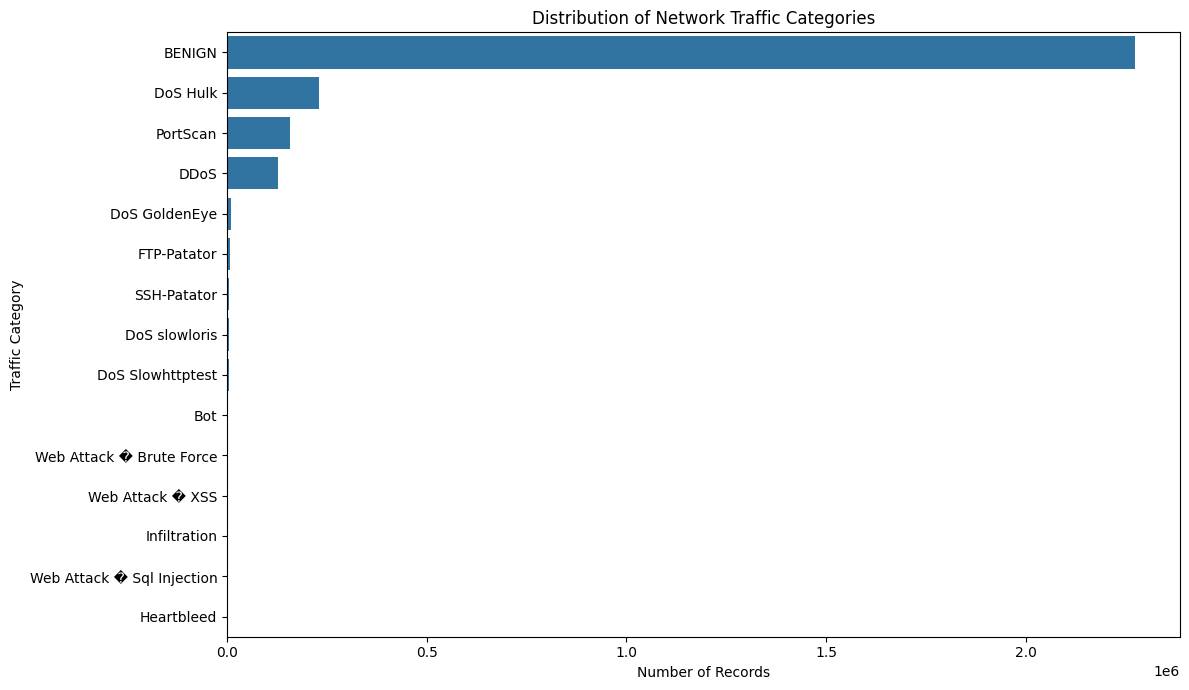

In [ ]:
# Create a horizontal bar chart showing the distribution
# of all network traffic categories.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Plot traffic categories from largest to smallest
sns.barplot(
    x=label_counts.values,
    y=label_counts.index
)

# Add descriptive title and axis labels
plt.title("Distribution of Network Traffic Categories")
plt.xlabel("Number of Records")
plt.ylabel("Traffic Category")

# Prevent labels from being cut off
plt.tight_layout()

# Display the chart
plt.show()

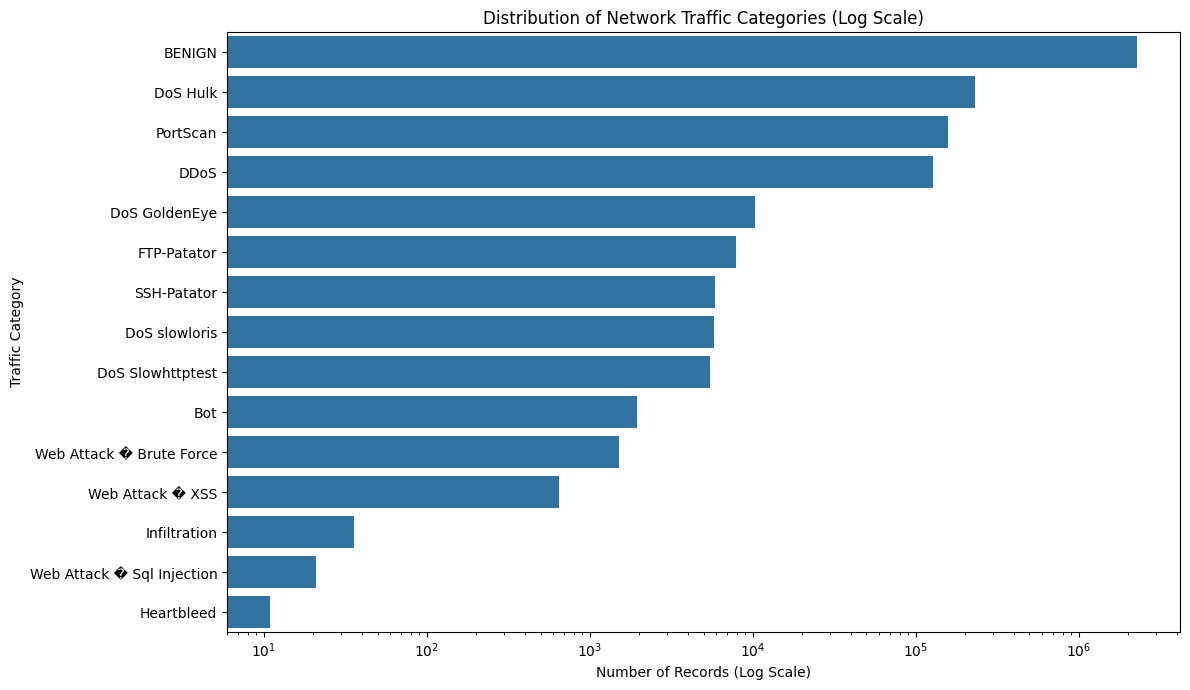

In [ ]:
# Create a bar chart showing the number of records
# using a logarithmic scale so rare attack categories
# can be compared with very large categories such as BENIGN.

plt.figure(figsize=(12, 7))

sns.barplot(
    x=label_counts.values,
    y=label_counts.index
)

# Convert the X-axis to logarithmic scale
plt.xscale('log')

# Add descriptive labels
plt.title("Distribution of Network Traffic Categories (Log Scale)")
plt.xlabel("Number of Records (Log Scale)")
plt.ylabel("Traffic Category")

# Keep the chart neatly formatted
plt.tight_layout()

# Display the chart
plt.show()

In [ ]:
# Select only the numerical columns from the dataset.
# The Label column contains text, so it is automatically excluded.

numeric_columns = df.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numeric_columns))

Number of numerical features: 78


In [ ]:
# Generate basic descriptive statistics for all numerical features.
# This helps us understand the range, average, spread, and quartiles.

numeric_summary = df[numeric_columns].describe().T

# Display the summary
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [ ]:
# Calculate the numerical range of every feature:
# range = maximum value - minimum value

feature_ranges = (
    df[numeric_columns].max() - df[numeric_columns].min()
).sort_values(ascending=False)

# Display the 15 features with the largest numerical ranges

print("Top 15 features by numerical range:")
print(feature_ranges.head(15))

Top 15 features by numerical range:
 Flow Packets/s                          inf
Flow Bytes/s                             inf
 Fwd Header Length.1            3.221688e+10
 Fwd Header Length              3.221688e+10
 Bwd Header Length              1.079580e+09
 Total Length of Bwd Packets    6.554530e+08
 Subflow Bwd Bytes              6.554530e+08
 min_seg_size_forward           5.368708e+08
 Flow IAT Min                   1.200000e+08
 Flow IAT Max                   1.200000e+08
 Flow IAT Mean                  1.200000e+08
 Fwd IAT Min                    1.200000e+08
 Flow Duration                  1.200000e+08
 Bwd IAT Min                    1.200000e+08
 Idle Min                       1.200000e+08
dtype: float64


In [ ]:
# Calculate the skewness of each numerical feature.
# A large positive value indicates a strong right-skew.

feature_skewness = (
    df[numeric_columns]
    .skew()
    .sort_values(ascending=False)
)

# Display the 15 most positively skewed features

print("Top 15 most positively skewed features:")
print(feature_skewness.head(15))

/usr/local/lib/python3.13/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


Top 15 most positively skewed features:
Total Length of Fwd Packets     805.570539
 Subflow Fwd Bytes              803.598592
 act_data_pkt_fwd               284.595228
 Total Backward Packets         244.679507
 Subflow Bwd Packets            244.679507
Subflow Fwd Packets             244.380553
 Total Fwd Packets              244.380553
 Subflow Bwd Bytes              244.335301
 Total Length of Bwd Packets    244.330893
 Fwd URG Flags                   94.781303
 CWE Flag Count                  94.781303
 RST Flag Count                  64.214112
 ECE Flag Count                  64.074059
 Active Min                      47.684006
 Active Std                      40.471707
dtype: float64


In [ ]:
# Remove leading and trailing spaces from the column names.
# This only changes the DataFrame currently loaded in Colab.
# The original raw CSV files remain completely untouched.

df.columns = df.columns.str.strip()

# Check a few column names to confirm the spaces were removed
print(df.columns[:10].tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


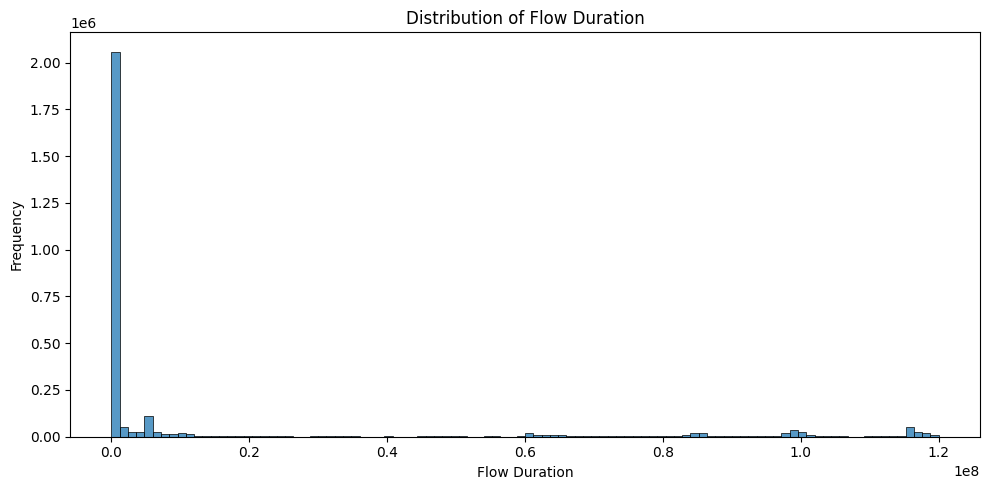

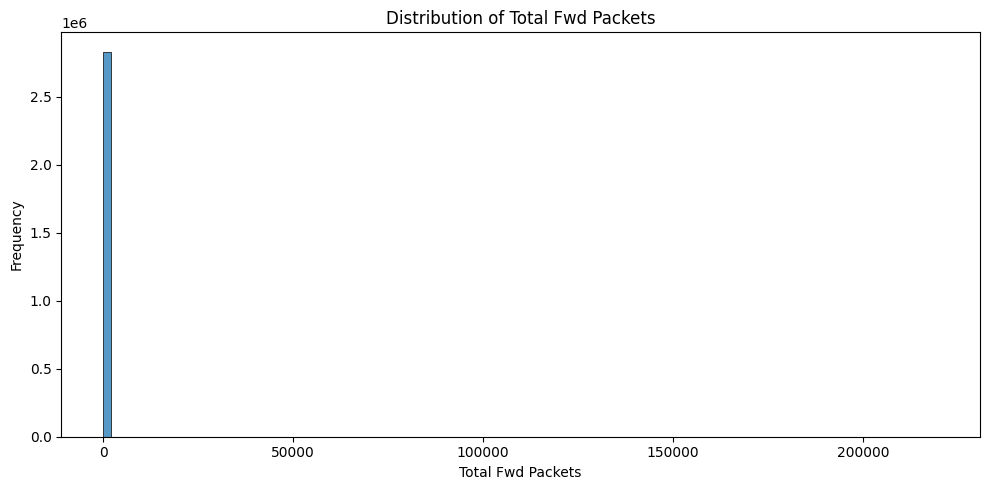

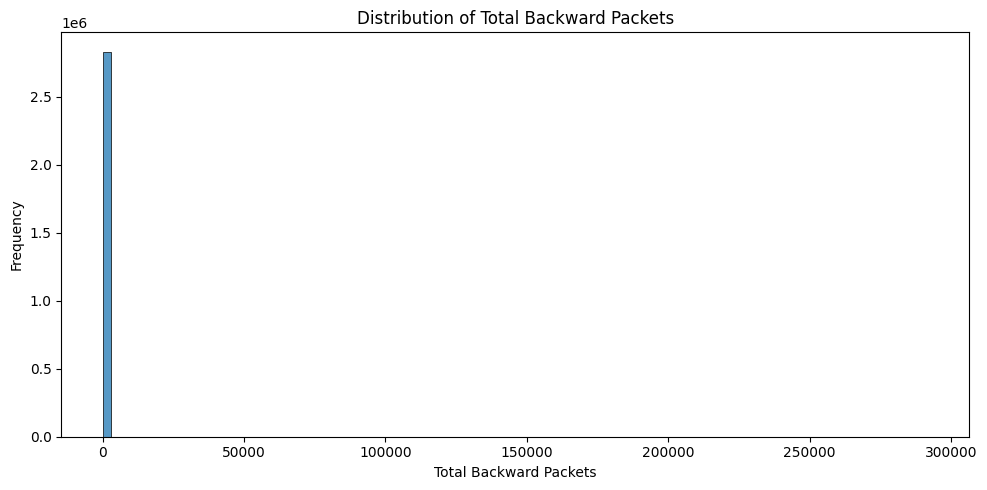

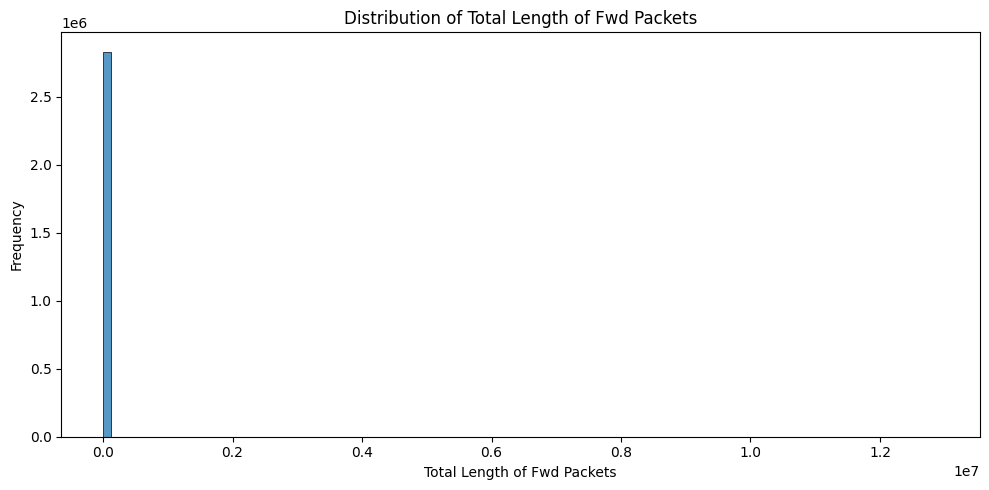

In [ ]:
# Select representative numerical features for distribution analysis
selected_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets'
]

# Plot the normal distribution of each selected feature
for feature in selected_features:

    plt.figure(figsize=(10, 5))

    # Create a histogram using the original values
    sns.histplot(
        df[feature],
        bins=100
    )

    # Add a clear title and axis labels
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Adjust spacing so everything is visible
    plt.tight_layout()

    # Display the graph
    plt.show()

In [ ]:
# Select only the numerical columns from the complete dataset.
# Our dataset has 78 numerical features and 1 Label column.

numeric_df = df.select_dtypes(include=np.number).copy()

# Replace infinite values with NaN only in this temporary DataFrame.
# This prevents infinity values from affecting our outlier calculations.
# The original df remains unchanged.

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

print("Number of numerical features:", numeric_df.shape[1])
print("Number of records:", numeric_df.shape[0])

Number of numerical features: 78
Number of records: 2830743


In [ ]:
# Calculate the first quartile (Q1) for every numerical feature.
Q1 = numeric_df.quantile(0.25)

# Calculate the third quartile (Q3) for every numerical feature.
Q3 = numeric_df.quantile(0.75)

# Calculate the Interquartile Range (IQR).
# IQR represents the range containing the middle 50% of observations.
IQR = Q3 - Q1

# Calculate the lower and upper boundaries used to identify outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
# Create a Boolean table indicating whether each value is an outlier.
# True  = value is outside the IQR boundaries
# False = value is within the expected range

outlier_mask = (
    (numeric_df < lower_bound) |
    (numeric_df > upper_bound)
)

# Count the number of outliers for every feature.
outlier_counts = outlier_mask.sum()

# Sort the features from the highest number of outliers to the lowest.
outlier_counts = outlier_counts.sort_values(ascending=False)

# Display the results for all 78 features.
print("Outlier count for each numerical feature:")
print(outlier_counts)

Outlier count for each numerical feature:
Fwd IAT Mean             671833
Fwd IAT Max              666292
Fwd IAT Total            665766
Fwd Packet Length Max    664214
Fwd Packet Length Std    663959
                          ...  
Fwd Avg Bulk Rate             0
Fwd Avg Packets/Bulk          0
Fwd Avg Bytes/Bulk            0
PSH Flag Count                0
ACK Flag Count                0
Length: 78, dtype: int64


In [ ]:
# Calculate the number of valid (non-missing and non-infinite)
# observations available for each feature.
valid_counts = numeric_df.notna().sum()

# Calculate the percentage of observations flagged as outliers.
outlier_percentages = (
    outlier_counts / valid_counts
) * 100

# Create a summary table combining the important information.
outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Valid Observations': valid_counts,
    'Outlier Percentage': outlier_percentages
})

# Sort the table by the number of outliers.
outlier_summary = outlier_summary.sort_values(
    by='Outlier Count',
    ascending=False
)

# Display the complete summary.
outlier_summary

,Outlier Count,Valid Observations,Outlier Percentage
Fwd IAT Mean,671833,2830743,23.733451
Fwd IAT Max,666292,2830743,23.537707
Fwd IAT Total,665766,2830743,23.519126
Fwd Packet Length Max,664214,2830743,23.464299
Fwd Packet Length Std,663959,2830743,23.455291
...,...,...,...
Bwd URG Flags,0,2830743,0.000000
Bwd PSH Flags,0,2830743,0.000000
Fwd Avg Bytes/Bulk,0,2830743,0.000000
Fwd Avg Bulk Rate,0,2830743,0.000000


In [ ]:
# Identify features where the IQR method found no outliers.

no_outliers = outlier_summary[
    outlier_summary['Outlier Count'] == 0
]

print("Number of features with no detected outliers:",
      len(no_outliers))

print("\nFeatures with no detected outliers:")
print(no_outliers.index.tolist())

Number of features with no detected outliers: 10

Features with no detected outliers:
['Bwd Avg Bulk Rate', 'ACK Flag Count', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd PSH Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'PSH Flag Count']


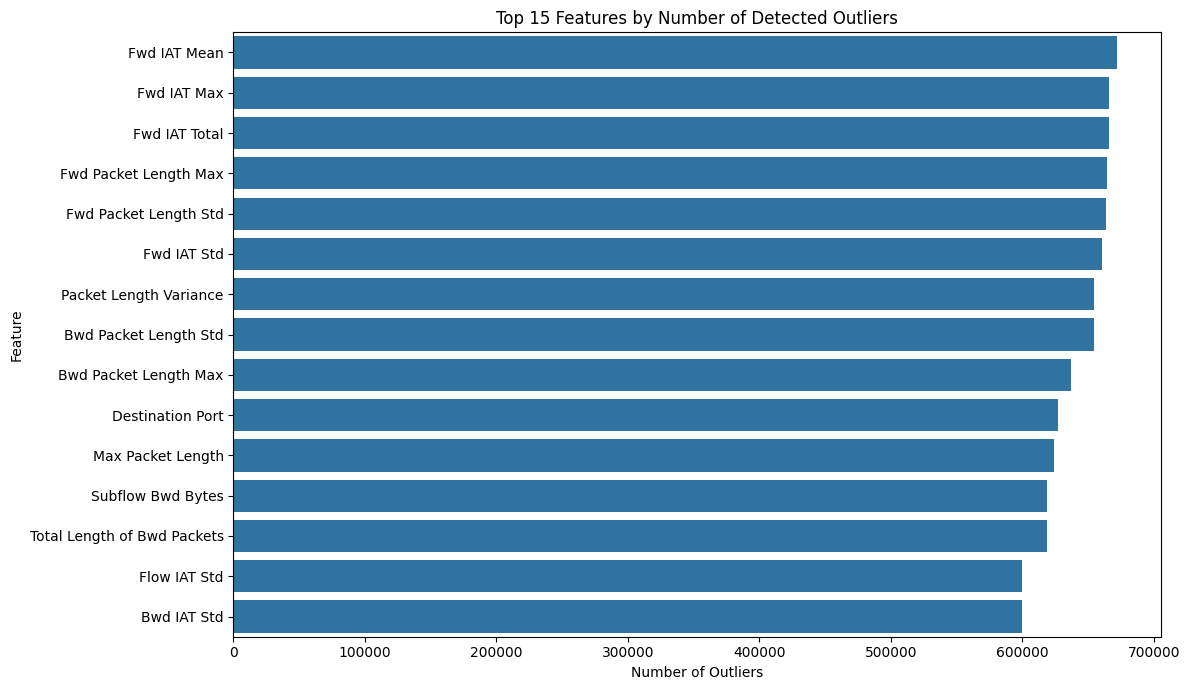

In [ ]:
# Select the 15 features with the highest number of detected outliers.
top_outlier_features = outlier_summary.head(15)

# Create a horizontal bar chart.
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_outlier_features['Outlier Count'],
    y=top_outlier_features.index
)

# Add chart title and labels.
plt.title("Top 15 Features by Number of Detected Outliers")
plt.xlabel("Number of Outliers")
plt.ylabel("Feature")

# Improve the layout.
plt.tight_layout()

# Display the chart.
plt.show()

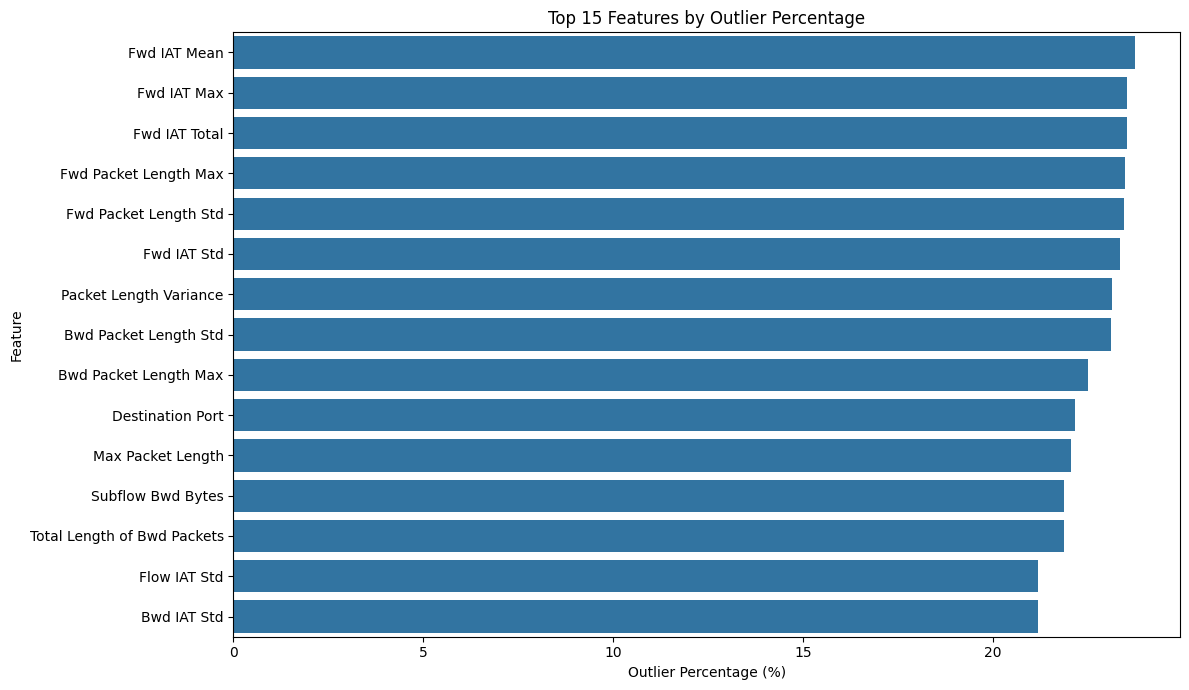

In [ ]:
# Select the 15 features with the highest percentage of outliers.
top_outlier_percentage = outlier_summary.sort_values(
    by='Outlier Percentage',
    ascending=False
).head(15)

# Create a horizontal bar chart.
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_outlier_percentage['Outlier Percentage'],
    y=top_outlier_percentage.index
)

# Add chart title and labels.
plt.title("Top 15 Features by Outlier Percentage")
plt.xlabel("Outlier Percentage (%)")
plt.ylabel("Feature")

# Improve the layout.
plt.tight_layout()

# Display the chart.
plt.show()

In [ ]:
# Calculate the Pearson correlation matrix for all 78 numerical features.
# This measures the strength and direction of linear relationships
# between pairs of numerical features.

correlation_matrix = numeric_df.corr()

print("Correlation matrix shape:", correlation_matrix.shape)

Correlation matrix shape: (78, 78)


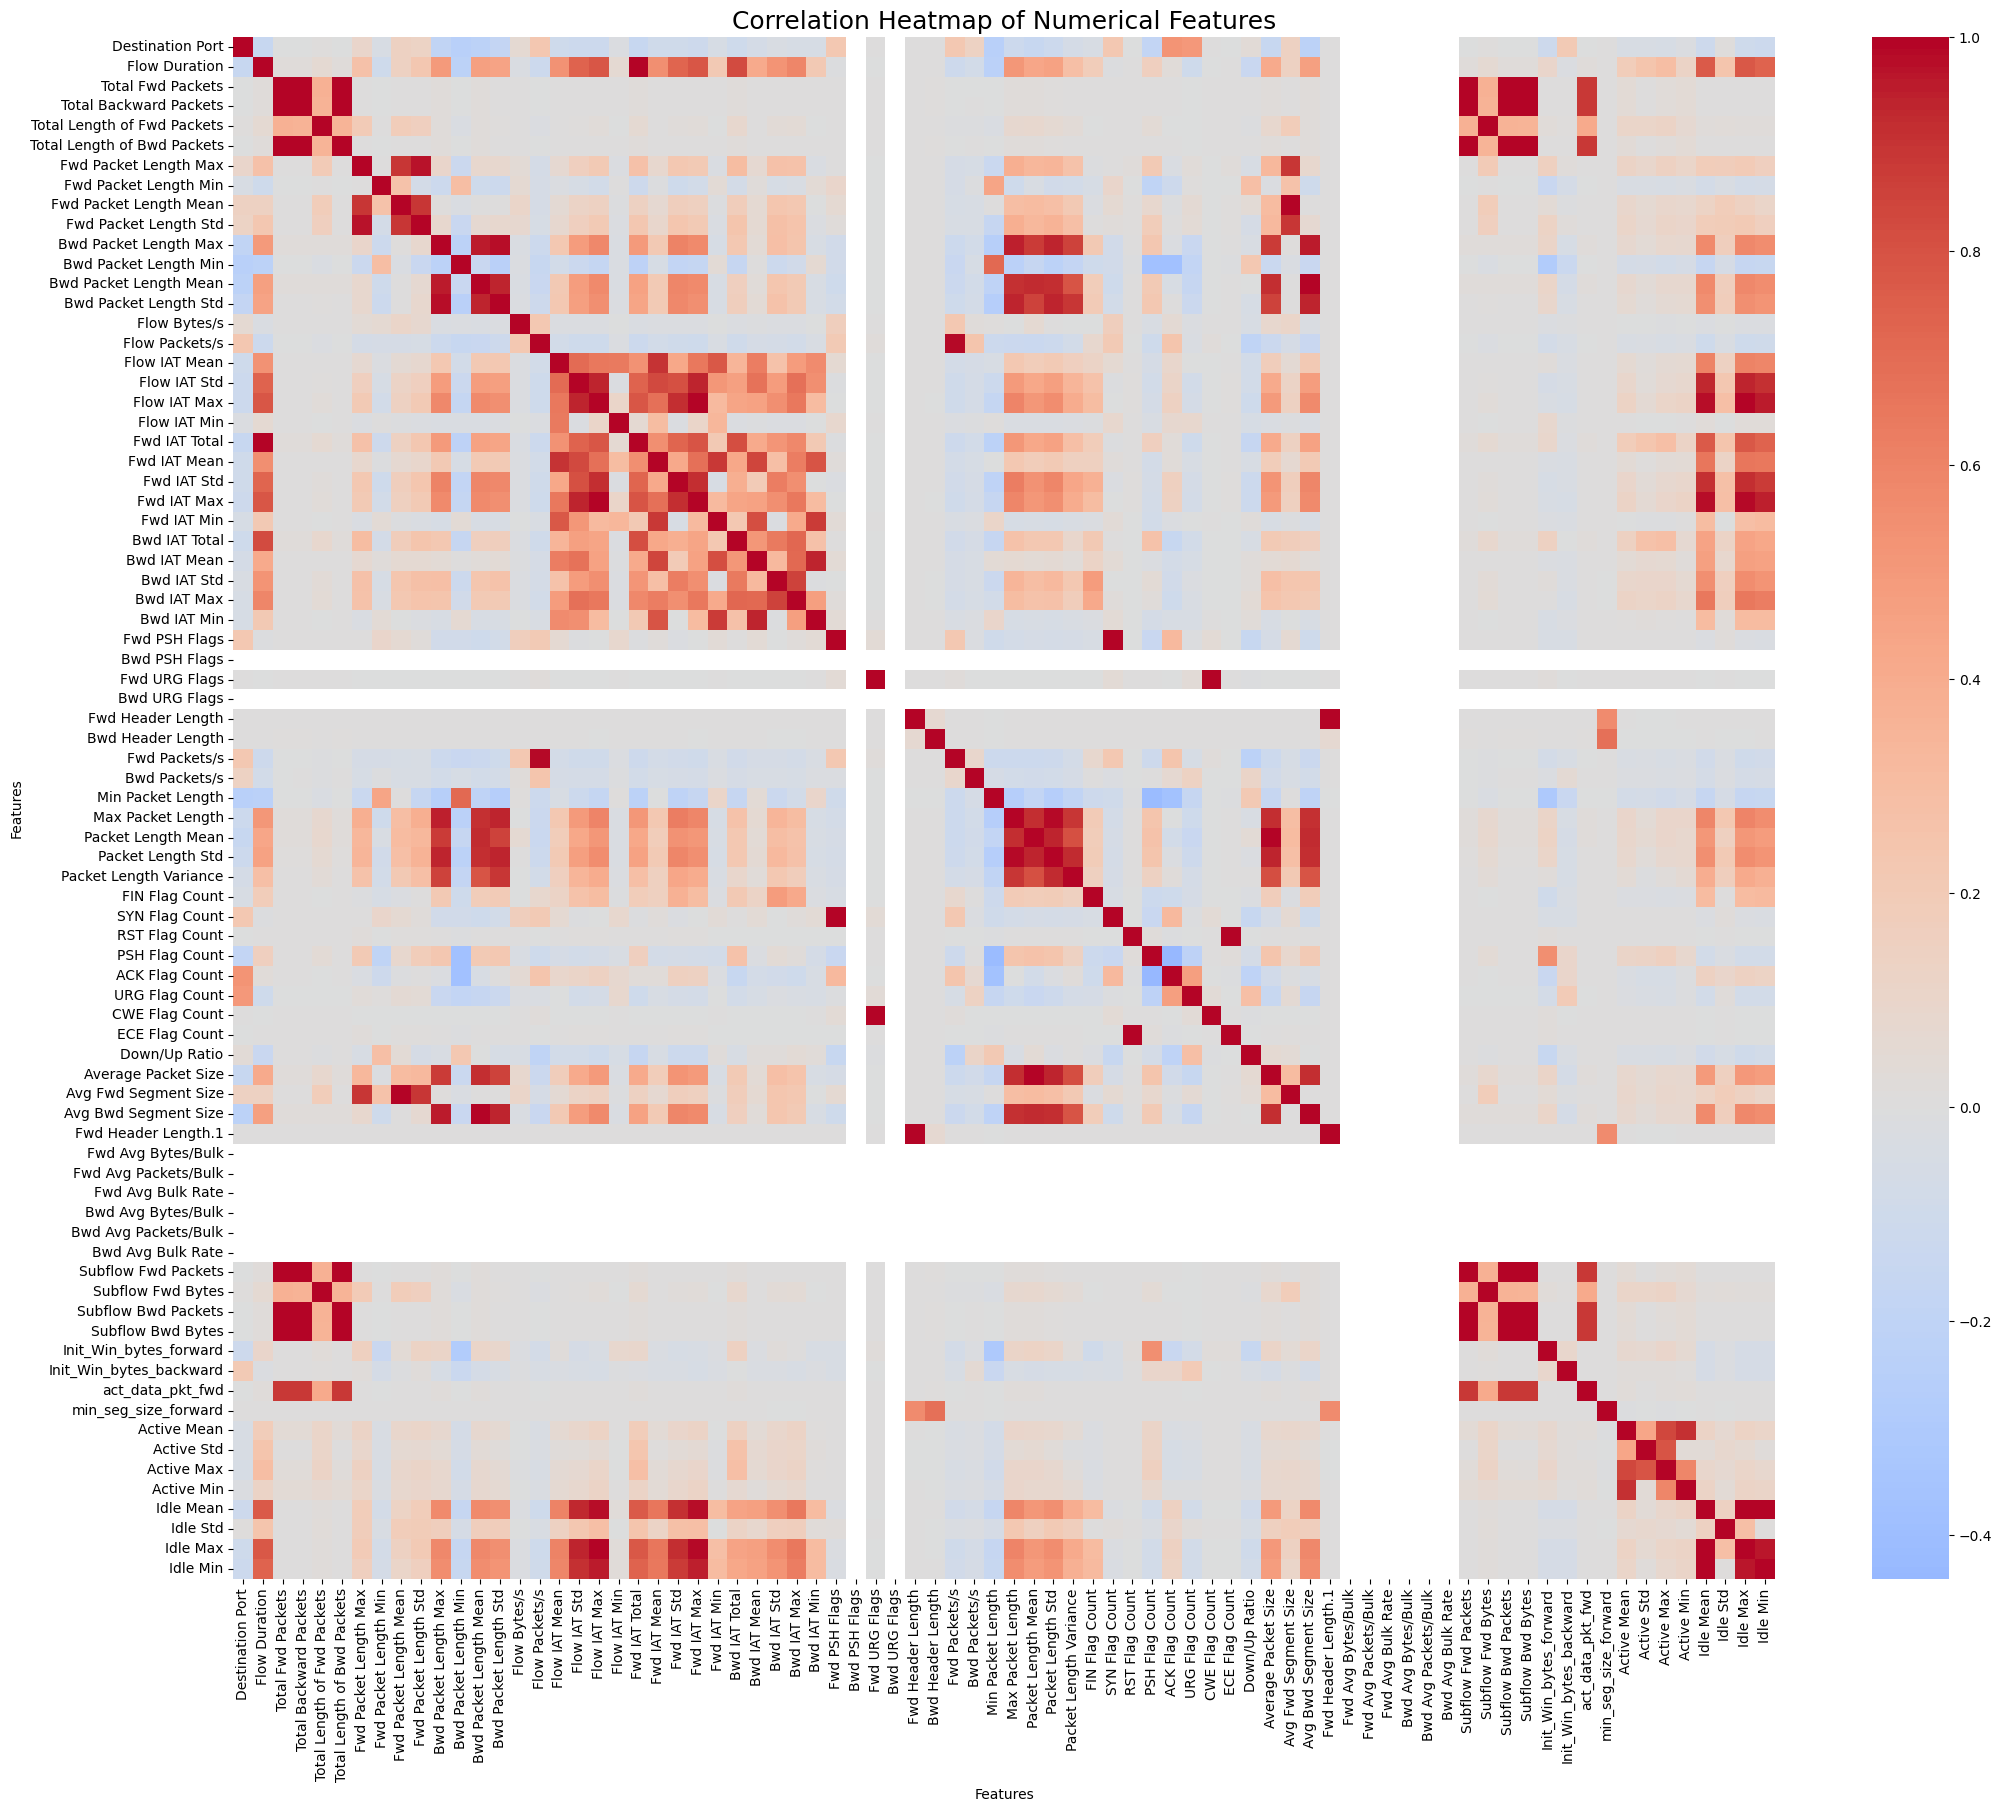

In [ ]:
# Calculate the correlation between all 78 numerical features.
# This creates a 78 × 78 correlation matrix for visualization.

correlation_matrix = numeric_df.corr()

# Visualize the complete correlation matrix as a heatmap.
# Strong positive correlations appear toward one end of the scale,
# strong negative correlations toward the other,
# and weak correlations near the middle.

plt.figure(figsize=(22, 18))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    xticklabels=True,
    yticklabels=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=18)
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

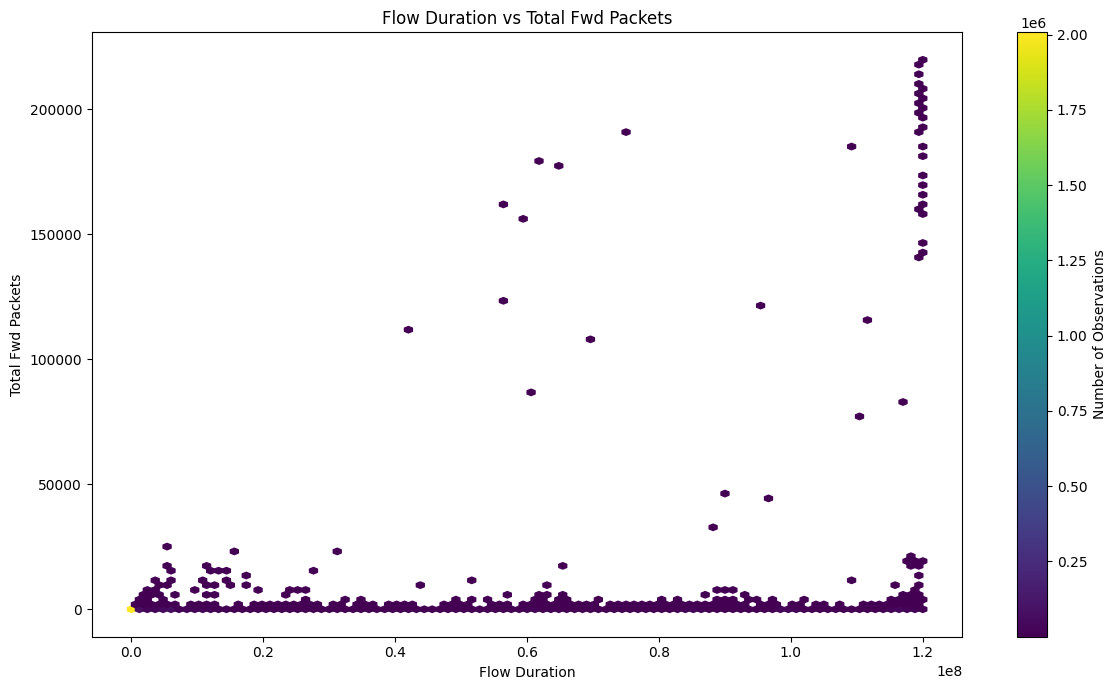

In [ ]:
# Visualize the relationship between Flow Duration
# and Total Fwd Packets using ALL observations.
#
# Hexbin is used instead of a normal scatter plot because
# our dataset contains around 2.83 million records.
# Every observation is still included in the visualization.

plt.figure(figsize=(12, 7))

plt.hexbin(
    df['Flow Duration'],
    df['Total Fwd Packets'],
    gridsize=100,
    mincnt=1
)

# Add a colorbar to show how many observations
# fall inside each hexagonal region.
plt.colorbar(label='Number of Observations')

# Add title and axis labels
plt.title('Flow Duration vs Total Fwd Packets')
plt.xlabel('Flow Duration')
plt.ylabel('Total Fwd Packets')

plt.tight_layout()
plt.show()

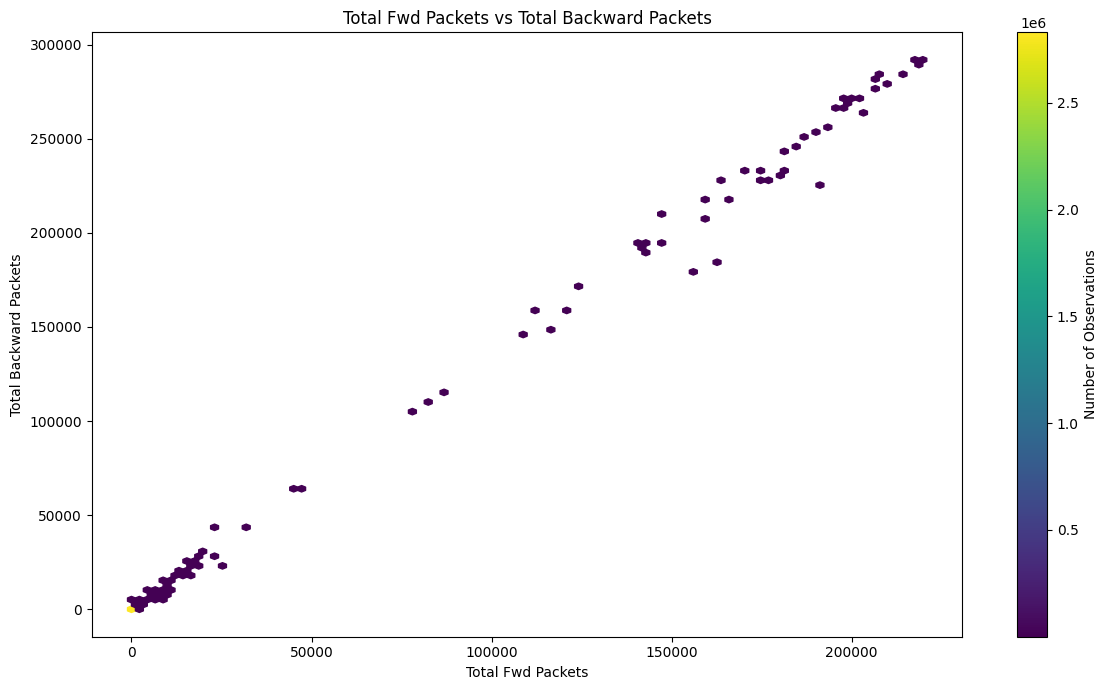

In [ ]:
# Visualize the relationship between forward and backward
# packet counts using ALL observations.

plt.figure(figsize=(12, 7))

plt.hexbin(
    df['Total Fwd Packets'],
    df['Total Backward Packets'],
    gridsize=100,
    mincnt=1
)

# Show the number of observations in each region
plt.colorbar(label='Number of Observations')

# Add title and axis labels
plt.title('Total Fwd Packets vs Total Backward Packets')
plt.xlabel('Total Fwd Packets')
plt.ylabel('Total Backward Packets')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the standard deviation of all 78 numerical features.
# A larger standard deviation means the feature has greater variation
# across the network-flow observations.

feature_std = numeric_df.std().sort_values(ascending=False)

# Display the 15 features with the highest variability
print("Top 15 features by standard deviation:")
print(feature_std.head(15))

Top 15 features by standard deviation:
Flow Duration          3.365374e+07
Fwd IAT Total          3.357581e+07
Bwd IAT Total          2.873661e+07
Flow Bytes/s           2.594016e+07
Fwd IAT Max            2.452916e+07
Flow IAT Max           2.445954e+07
Idle Max               2.436689e+07
Idle Mean              2.363008e+07
Idle Min               2.336342e+07
Fwd Header Length.1    2.105286e+07
Fwd Header Length      2.105286e+07
Bwd IAT Max            1.716095e+07
Fwd IAT Std            9.639055e+06
Fwd IAT Mean           9.525722e+06
Bwd IAT Mean           8.887197e+06
dtype: float64


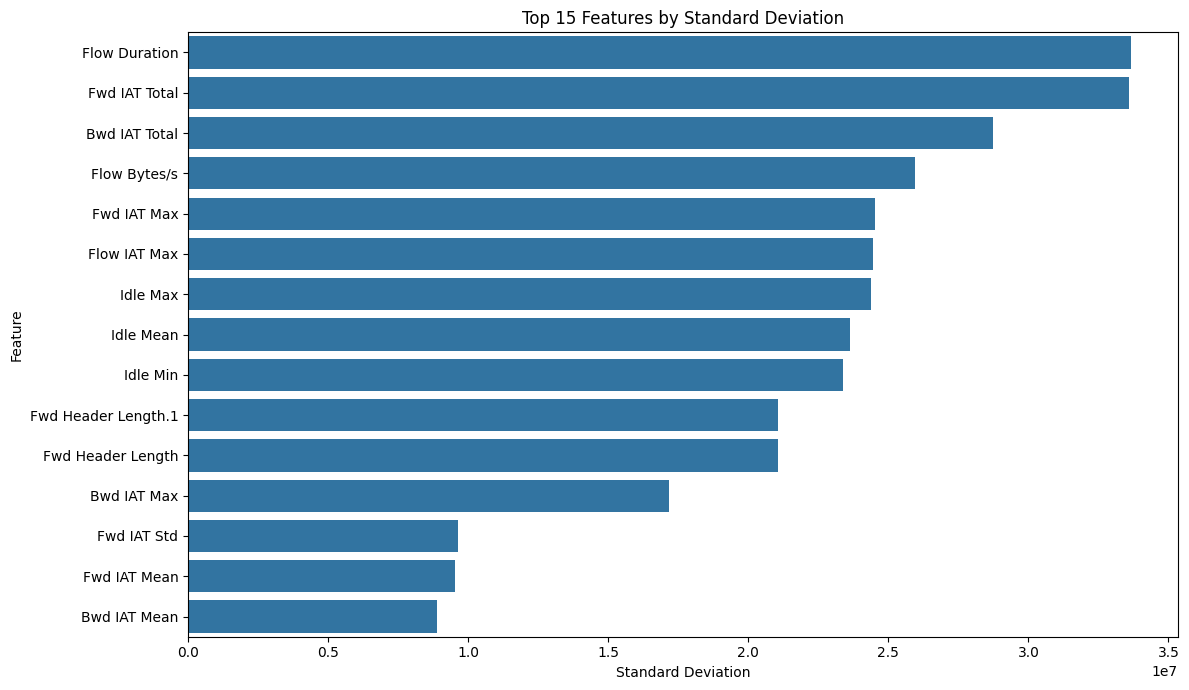

In [ ]:
# Select the 15 features with the highest standard deviation.
# These features show the greatest numerical variation in the dataset.

top_variable_features = feature_std.head(15)

# Create a horizontal bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_variable_features.values,
    y=top_variable_features.index
)

# Add title and axis labels
plt.title("Top 15 Features by Standard Deviation")
plt.xlabel("Standard Deviation")
plt.ylabel("Feature")

# Format the graph
plt.tight_layout()
plt.show()

In [22]:
# =========================================================
# STAGE 3: Final Feature Selection (CORRECTED — dedup on full
# feature set BEFORE narrowing to 7 columns, so near-duplicate
# minority attack flows like PortScan aren't wiped out)
# =========================================================
import numpy as np

final_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Fwd Packet Length Mean',
    'SYN Flag Count',
    'Down/Up Ratio'
]

label_col = 'Label'

# Ensure column names are stripped of leading/trailing spaces before use
df.columns = df.columns.str.strip()

# Clean and deduplicate on the FULL dataset (all 78 features) first —
# this is the fix. Deduping on just 7 columns was incorrectly treating
# genuinely distinct flows (especially short PortScan probes) as duplicates.
work_df_full = df.replace([np.inf, -np.inf], np.nan).dropna()

before = work_df_full.shape[0]
work_df_full = work_df_full.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - work_df_full.shape[0]} true duplicate rows (compared across all features)")
print("Full cleaned shape:", work_df_full.shape)

# NOW narrow down to just the 7 selected features + label
work_df = work_df_full[final_features + [label_col]].copy()
print("Working shape after feature selection:", work_df.shape)

# Stratified sample — full dataset is too large for Hierarchical Clustering (O(n^2))
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 20000
X_sample, _, y_sample, _ = train_test_split(
    work_df[final_features], work_df[label_col],
    train_size=SAMPLE_SIZE, stratify=work_df[label_col], random_state=42
)
X_sample = X_sample.reset_index(drop=True)
y_sample = y_sample.reset_index(drop=True)
print("Sampled shape:", X_sample.shape)
print(y_sample.value_counts())

Dropped 307078 true duplicate rows (compared across all features)
Full cleaned shape: (2520798, 79)
Working shape after feature selection: (2520798, 8)
Sampled shape: (20000, 7)
Label
BENIGN                      16622
DoS Hulk                     1371
DDoS                         1016
PortScan                      720
DoS GoldenEye                  82
FTP-Patator                    47
DoS slowloris                  43
DoS Slowhttptest               41
SSH-Patator                    26
Bot                            15
Web Attack � Brute Force       12
Web Attack � XSS                5
Name: count, dtype: int64


In [23]:
print(y_sample.value_counts())
print("\nTotal categories in full cleaned data:", work_df[label_col].nunique())
print("Total categories in sample:", y_sample.nunique())

Label
BENIGN                      16622
DoS Hulk                     1371
DDoS                         1016
PortScan                      720
DoS GoldenEye                  82
FTP-Patator                    47
DoS slowloris                  43
DoS Slowhttptest               41
SSH-Patator                    26
Bot                            15
Web Attack � Brute Force       12
Web Attack � XSS                5
Name: count, dtype: int64

Total categories in full cleaned data: 15
Total categories in sample: 12


In [32]:

# STAGE 4: Feature Scaling
from sklearn.preprocessing import StandardScaler

# Log-transform the two heavily skewed rate/volume features before scaling
# (Flow Bytes/s and Flow Duration both have extreme right-skew — confirmed
# in your own skewness analysis, cell 15)
X_transformed = X_sample[final_features].copy()
for col in ['Flow Duration', 'Flow Bytes/s']:
    X_transformed[col] = np.log1p(X_transformed[col].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (20000, 7)


k=2  inertia=115235.1  silhouette=0.348
k=3  inertia=95237.8  silhouette=0.347
k=4  inertia=76614.2  silhouette=0.384
k=5  inertia=60552.6  silhouette=0.395
k=6  inertia=50946.5  silhouette=0.372
k=7  inertia=40959.0  silhouette=0.392
k=8  inertia=33543.6  silhouette=0.468


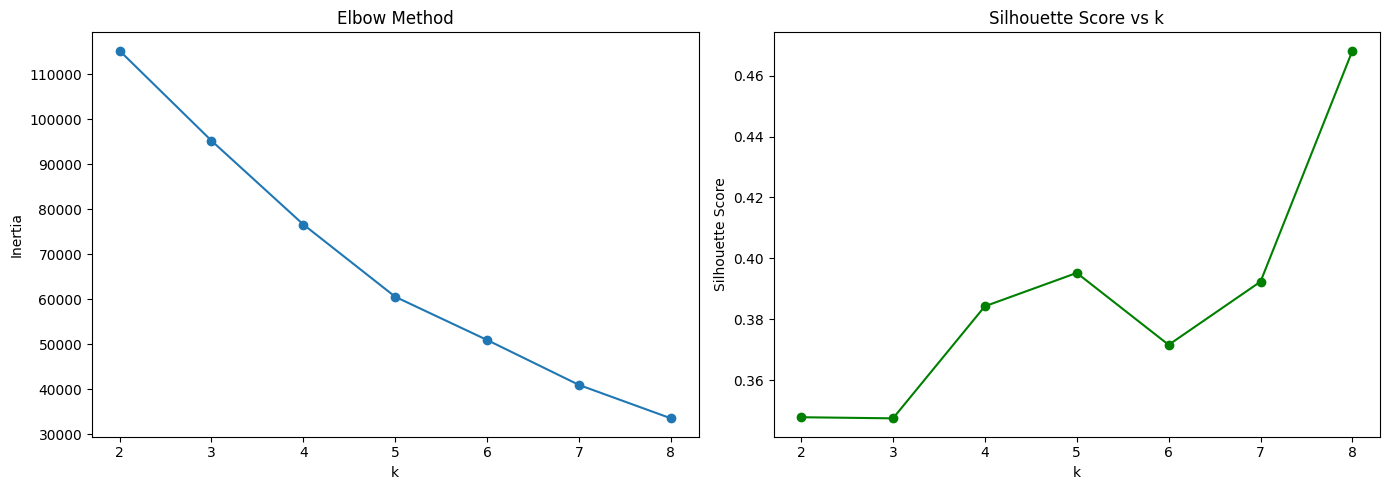

In [33]:
# =======================================================
# STAGE 5: K-Means — Choosing k
# =========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.3f}")

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].set_title("Silhouette Score vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

In [34]:
# =========================================================
# STAGE 6: Final K-Means Model
# =========================================================
K_FINAL = 4  # <-- update based on Stage 5 chart

kmeans_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

X_sample['kmeans_cluster'] = kmeans_labels
print(X_sample['kmeans_cluster'].value_counts())

kmeans_cluster
2    12875
1     6160
0      964
3        1
Name: count, dtype: int64


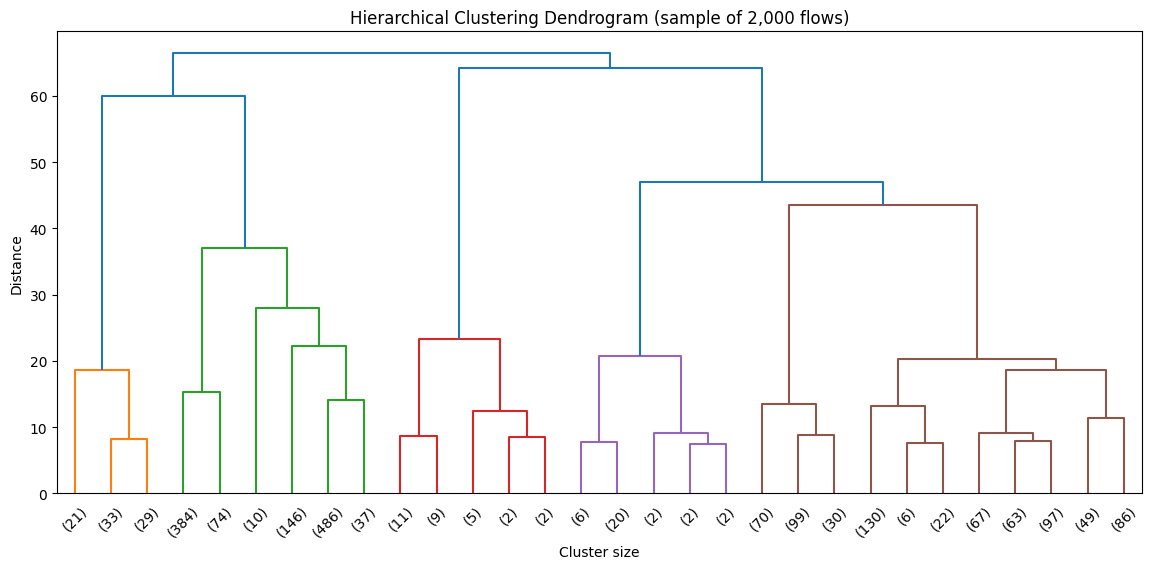

hierarchical_cluster
3    10162
1     8726
0     1111
2        1
Name: count, dtype: int64


In [35]:
  # =========================================================
# STAGE 7: Hierarchical / Agglomerative Clustering
# =========================================================
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Ward linkage minimizes within-cluster variance — standard choice when
# using Euclidean distance on scaled numeric features (matches K-Means' objective,
# which makes the two algorithms genuinely comparable)
# NOTE: dendrogram is drawn on a smaller sub-sample (2000 rows) purely for
# readability — with 20,000 rows the dendrogram becomes an unreadable smear
dendro_sample_idx = np.random.RandomState(42).choice(len(X_scaled), 2000, replace=False)
linked = linkage(X_scaled[dendro_sample_idx], method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram (sample of 2,000 flows)")
plt.xlabel("Cluster size"); plt.ylabel("Distance")
plt.show()

# Full agglomerative fit on the 20,000-row sample for actual cluster assignments
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)
X_sample['hierarchical_cluster'] = agglo_labels
print(X_sample['hierarchical_cluster'].value_counts())

In [36]:
# =========================================================
# STAGE 8: Evaluation
# =========================================================
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

results = {}
for name, labels in [('K-Means', kmeans_labels), ('Hierarchical', agglo_labels)]:
    results[name] = {
        'Silhouette': silhouette_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
    }

results_df = pd.DataFrame(results).T
print(results_df.round(3))

              Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means            0.384           0.827           5514.487
Hierarchical       0.348           0.954           5102.269


In [37]:
# =========================================================
# STAGE 9: PCA (3D) + Export for Dashboard
# =========================================================
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X_scaled)
print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance explained by 3 components:", pca.explained_variance_ratio_.sum())

X_sample['pca_x'] = coords[:, 0]
X_sample['pca_y'] = coords[:, 1]
X_sample['pca_z'] = coords[:, 2]
X_sample['true_label'] = y_sample.values

# Export — this CSV is what your local dashboard will load
X_sample.to_csv('clustered_traffic_results.csv', index=False)

from google.colab import files
files.download('clustered_traffic_results.csv')

Explained variance ratio per component: [0.27161892 0.16659942 0.14982552]
Total variance explained by 3 components: 0.5880438665726688


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# =========================================================
# STAGE 10: Cluster Interpretation (per-cluster profile)
# =========================================================
from sklearn.cluster import KMeans

# Re-run K-Means to ensure kmeans_cluster is available in X_sample
kmeans_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
X_sample['kmeans_cluster'] = kmeans_labels

for cid in sorted(X_sample['kmeans_cluster'].unique()):
    sub = X_sample[X_sample['kmeans_cluster'] == cid]
    print(f"\n=== Cluster {cid} (n={len(sub)}, {len(sub)/len(X_sample)*100:.1f}% of sample) ===")
    print("Label composition:")
    print(sub['true_label'].value_counts(normalize=True).round(3) * 100)
    print("\nFeature averages:")
    print(sub[final_features].mean().round(2))


=== Cluster 0 (n=964, 4.8% of sample) ===
Label composition:
true_label
BENIGN              96.3
FTP-Patator          2.1
DoS slowloris        1.2
DoS Slowhttptest     0.4
Name: proportion, dtype: float64

Feature averages:
Flow Duration             13573683.92
Total Fwd Packets                6.95
Flow Bytes/s              22152588.86
Flow IAT Mean              2912715.37
Fwd Packet Length Mean         113.82
SYN Flag Count                   1.00
Down/Up Ratio                    0.23
dtype: float64

=== Cluster 1 (n=6160, 30.8% of sample) ===
Label composition:
true_label
BENIGN                      68.2
DoS Hulk                    18.8
DDoS                         9.4
DoS GoldenEye                1.3
DoS Slowhttptest             0.6
DoS slowloris                0.5
FTP-Patator                  0.4
SSH-Patator                  0.4
Web Attack � Brute Force     0.2
PortScan                     0.1
Web Attack � XSS             0.1
Bot                          0.1
Name: proportion, dtype

In [40]:
print(X_sample.groupby('true_label')['SYN Flag Count'].mean().sort_values(ascending=False))

true_label
FTP-Patator                 0.425532
DoS slowloris               0.279070
DoS Slowhttptest            0.097561
BENIGN                      0.055830
DoS GoldenEye               0.000000
DDoS                        0.000000
Bot                         0.000000
DoS Hulk                    0.000000
PortScan                    0.000000
SSH-Patator                 0.000000
Web Attack � Brute Force    0.000000
Web Attack � XSS            0.000000
Name: SYN Flag Count, dtype: float64


In [41]:
print(X_sample.groupby('true_label')[final_features].mean().round(2))

                          Flow Duration  Total Fwd Packets  Flow Bytes/s  \
true_label                                                                 
BENIGN                      12338800.71              18.68    1687100.77   
Bot                           369934.00               2.87      92561.96   
DDoS                        19002059.66               4.63     317129.31   
DoS GoldenEye               18256103.20               6.24        784.25   
DoS Hulk                    75692759.15               6.30      45449.26   
DoS Slowhttptest            55425876.83               6.41    4410878.32   
DoS slowloris               65883718.14               7.33       5539.14   
FTP-Patator                  5259724.15               6.00     208631.82   
PortScan                      282017.15               1.02     255404.22   
SSH-Patator                 11157658.58              19.62        364.92   
Web Attack � Brute Force     5610720.83               3.00          0.00   
Web Attack �

In [42]:
kmeans_k7 = KMeans(n_clusters=7, n_init=10, random_state=42)
labels_k7 = kmeans_k7.fit_predict(X_scaled)
X_sample['kmeans_k7'] = labels_k7

for cid in sorted(X_sample['kmeans_k7'].unique()):
    sub = X_sample[X_sample['kmeans_k7'] == cid]
    print(f"\n=== Cluster {cid} (n={len(sub)}) ===")
    print(sub['true_label'].value_counts(normalize=True).round(3).head(4) * 100)


=== Cluster 0 (n=4776) ===
true_label
BENIGN      82.5
PortScan    15.0
DDoS         1.8
DoS Hulk     0.6
Name: proportion, dtype: float64

=== Cluster 1 (n=4907) ===
true_label
BENIGN           62.2
DoS Hulk         22.6
DDoS             11.6
DoS GoldenEye     1.3
Name: proportion, dtype: float64

=== Cluster 2 (n=1) ===
true_label
BENIGN    100.0
Name: proportion, dtype: float64

=== Cluster 3 (n=8927) ===
true_label
BENIGN         92.9
DDoS            4.0
DoS Hulk        2.6
SSH-Patator     0.3
Name: proportion, dtype: float64

=== Cluster 4 (n=887) ===
true_label
BENIGN              97.3
FTP-Patator          2.3
DoS Slowhttptest     0.3
DoS slowloris        0.1
Name: proportion, dtype: float64

=== Cluster 5 (n=275) ===
true_label
BENIGN           88.4
DoS GoldenEye     4.7
DoS slowloris     4.0
DoS Hulk          1.1
Name: proportion, dtype: float64

=== Cluster 6 (n=227) ===
true_label
BENIGN              99.6
DoS Slowhttptest     0.4
Name: proportion, dtype: float64
